[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# Bending of a quarter circle under out-of-plane force

Last updated: 07/15/26

## Problem description

Fixed at the end, circular arc of 90 degrees made from hollow round section;
elastic linear material.

Radius of the circle = 3 m, upper end fixed. Section: R=10mm, thickness=2mm
(Ax=1.0), E=2e11.

Displacements are provided in the manual.

## References

This is the AFNOR SSLL06/89 test case.

Original source: "Guide de validation des progiciels de calcul de structures"
publié par l'AFNOR 1990 (ISBN 2-12-486611-7).

Data taken from: ICAB Force Exemples Exemples de calculs de statique pour ICAB
Force. www.icab.fr

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [17]:
import context
from pystran import model
from pystran import section
from pystran import rotation
from pystran import plots
from numpy import array, dot, pi
from numpy.linalg import norm
from math import cos, sin, pi

Let us define a few constants.

In [18]:
CIRCLE_RADIUS = 1000.0  # mm
SECTION_RADIUS = 10.0  # mm
SECTION_THICKNESS = 2.0  # mm
E = 2e5  # MPa
G = 7.6923e4  # MPa

In [19]:
m = model.create(3)
freedoms = m["freedoms"]

The mesh is generated along the arc.


In [20]:
NUM_JOINTS = 15
for k in range(NUM_JOINTS):
    a = pi / 2 - k / (NUM_JOINTS - 1) * pi / 2
    model.add_joint(m, k, [CIRCLE_RADIUS * cos(a), CIRCLE_RADIUS * sin(a), 0.0])

One end is clamped.


In [21]:
model.add_support(m["joints"][0], freedoms.ALL_DOFS)

The other one is loaded out of the plane of the orc.


In [22]:
model.add_load(m["joints"][NUM_JOINTS - 1], freedoms.U3, 100)

The cross section is a circular tube, and we first use a utility to calculate
the cross section properties.


In [23]:
A, Ix, Iy, Iz, J = section.circular_tube(
    SECTION_RADIUS - SECTION_THICKNESS, SECTION_RADIUS
)
xz_vector = [0, 0, 1]
sect_1 = section.beam_3d_section(
    "sect_1", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Now we generate the beam members.


In [24]:
for k in range(NUM_JOINTS - 1):
    model.add_beam_member(m, k, [k, k + 1], sect_1)

A handful of plots to review the supports and the loads.


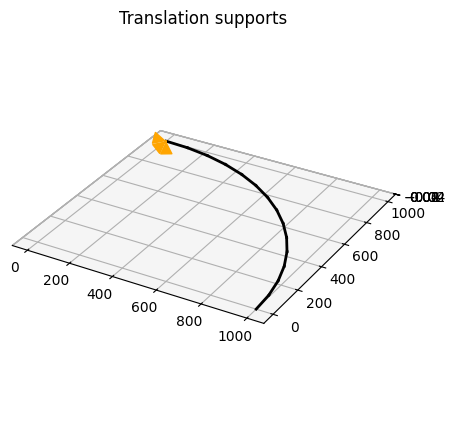

In [25]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_translation_supports(m)
ax.set_title("Translation supports")
plots.show(m)

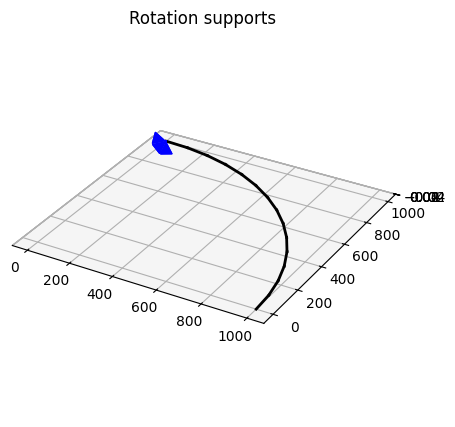

In [26]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_rotation_supports(m)
ax.set_title("Rotation supports")
plots.show(m)

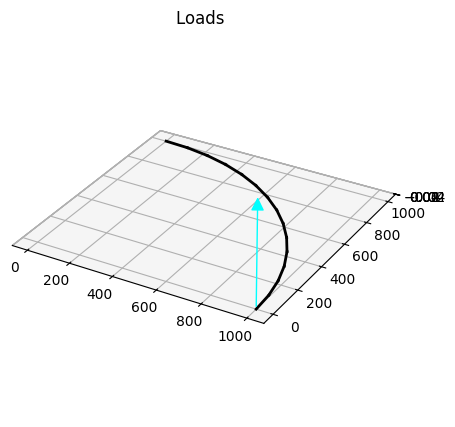

In [27]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_applied_forces(m, 5)
ax.set_title("Loads ")
plots.show(m)

We solve the static problem, and report the displacements at the free end.


In [28]:
model.number_dofs(m)
model.solve_statics(m)

In [29]:
print(m["joints"][NUM_JOINTS - 1]["displacements"])

[ 0.00000000e+00  0.00000000e+00  1.34327647e+02 -1.23756895e-01
 -5.47244205e-02  0.00000000e+00]


The displacement in the direction of the force is checked against the benchmark.


In [30]:
if abs(m["joints"][NUM_JOINTS - 1]["displacements"][2] - 134.33) > 0.01:
    raise ValueError("Displacement calculation error")

Plot the deformation.


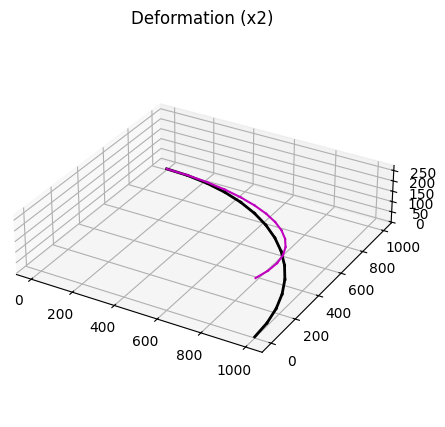

In [31]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_deformations(m, scale=2.0)
ax.set_title("Deformation (x2)")
plots.show(m)

Also plot the torsion moment.


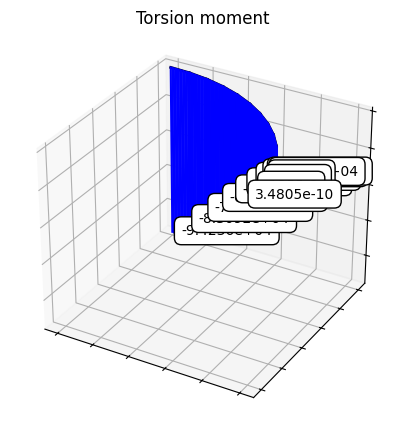

In [32]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_torsion_moments(m, scale=0.01)
ax.set_title("Torsion moment")
plots.show(m)

## Conclusions

The package has only a straight beam element. In order to approximate a curved member, we should generate a few elements along its length.